In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
df = pd.read_csv('TX_housing_market_2026.csv')

# Filter for Single Family and fix dates
df['PERIOD_BEGIN'] = pd.to_datetime(df['PERIOD_BEGIN'])
df_sf = df[df['PROPERTY_TYPE'] == 'Single Family Residential'].copy()

df_sf['SALE_TO_LIST_RATIO'] = df_sf['AVG_SALE_TO_LIST'] # Assuming this is your variable name

# Drop rows with missing values in key analytical columns
clean_df = df_sf.dropna(subset=['MEDIAN_SALE_PRICE', 'MEDIAN_DOM', 'PRICE_DROPS', 'MONTHS_OF_SUPPLY']).copy()

### Data Analysis Exploratory

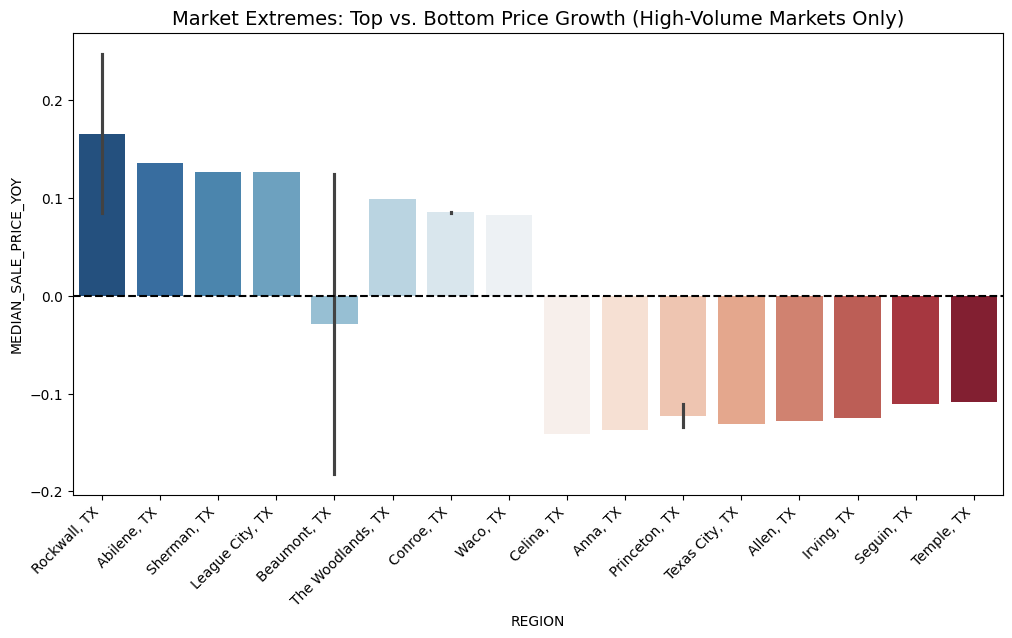

In [ ]:
# 2. DESCRIPTIVE VISUALIZATION

significant_markets = clean_df[clean_df['HOMES_SOLD'] >= 50]  # Only keep regions where at least 50 homes were sold in that period

# 2. Grab the Top and Bottom 10
top_10 = significant_markets.nlargest(10, 'MEDIAN_SALE_PRICE_YOY')
bottom_10 = significant_markets.nsmallest(10, 'MEDIAN_SALE_PRICE_YOY')
extremes = pd.concat([top_10, bottom_10])

# 3. Plot the extremes
plt.figure(figsize=(12, 6))
sns.barplot(
    data=extremes, 
    x='REGION', 
    y='MEDIAN_SALE_PRICE_YOY', 
    hue='REGION',
    palette='RdBu_r',
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title('Market Extremes: Top vs. Bottom Price Growth (High-Volume Markets Only)', fontsize=14)
plt.axhline(0, color='black', ls='--') 
plt.show()

When looking at the this graph, we will see the growth markets. Cities like Rockwall, Abilene, Sherman, and League City are double digit price appreciation(over 10%). What they have in common is they are outer ring suburbs. Furthermore, we are seeing the moving out of city center trend here. That's why we see the housing markets in the suburbs of big cities are vibrant.

On the right side, we are seeing 10% to 15% price drops in places like Celina, Anna, Princeton, and Allen. These cities are fast growing suburbs in North Dallas. During the pandemic, builders flooded these areas with new construction. Now, in 2026, the sharp increase in inventory has shifted the balance, forcing sellers to lower prices to remain competitive.

### Market Segmentation


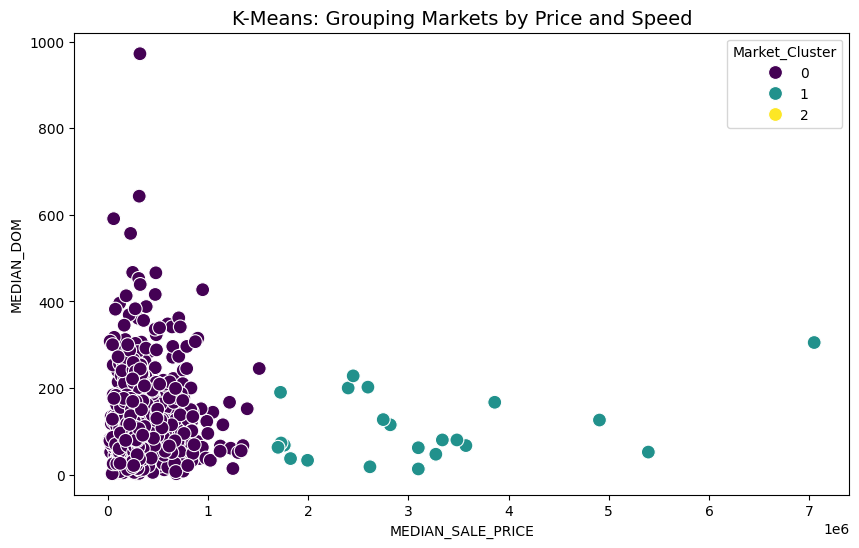

In [ ]:
# K-MEANS CLUSTERING 


features = ['MEDIAN_SALE_PRICE', 'MEDIAN_DOM', 'MONTHS_OF_SUPPLY', 'PRICE_DROPS']
X = clean_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clean_df['Market_Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_df, 
    x='MEDIAN_SALE_PRICE', 
    y='MEDIAN_DOM', 
    hue='Market_Cluster', 
    palette='viridis', 
    s=100
)
plt.title('K-Means: Grouping Markets by Price and Speed', fontsize=14)
plt.show()

In [13]:
print(f"Total Records Analyzed: {len(clean_df)}")
cluster_summary = clean_df.groupby('Market_Cluster')[['MEDIAN_SALE_PRICE', 'MEDIAN_DOM']].mean()
print("\nCluster Characteristics:")
print(cluster_summary)

Total Records Analyzed: 1265

Cluster Characteristics:
                MEDIAN_SALE_PRICE  MEDIAN_DOM
Market_Cluster                               
0                    3.365315e+05  108.498387
1                    3.066482e+06  106.954545
2                    2.408333e+05  167.333333


When we look at this scratter plot graph, We observe a clear differentiation in the market regarding house values. There are 3 types of market. Mainstream market (under 1.5 million), luxury market (from 1.5 to 7 million) and ultra luxury market (over 7 million)
Purple dots (Cluster 0) shows homes roughly under 1.5 million. This cluster is considerred as mainstream Texas housing market. We notice that these dots spread verticle massively. We have home selling in very short time, and other sitting for almost 1000 days. Based on the cluster characteristic, it take 108 days to sell a home in average. This is a strong proof that price alone does not predict how fast a home will be sold. It depends on many other conditions such as location, interest rate, conditions of the houses, etc.
Blue dots (cluster 1) shows the luxury housing market. In theory, we may assume that these house are hard to sell. But according the data, these luxury homes only take 107 days which is about the same with mainstream market. This strongly show that the luxury home buyers at the begining of 2026 will not be affected by the high morgate interest rates. 

### Predicting Prices

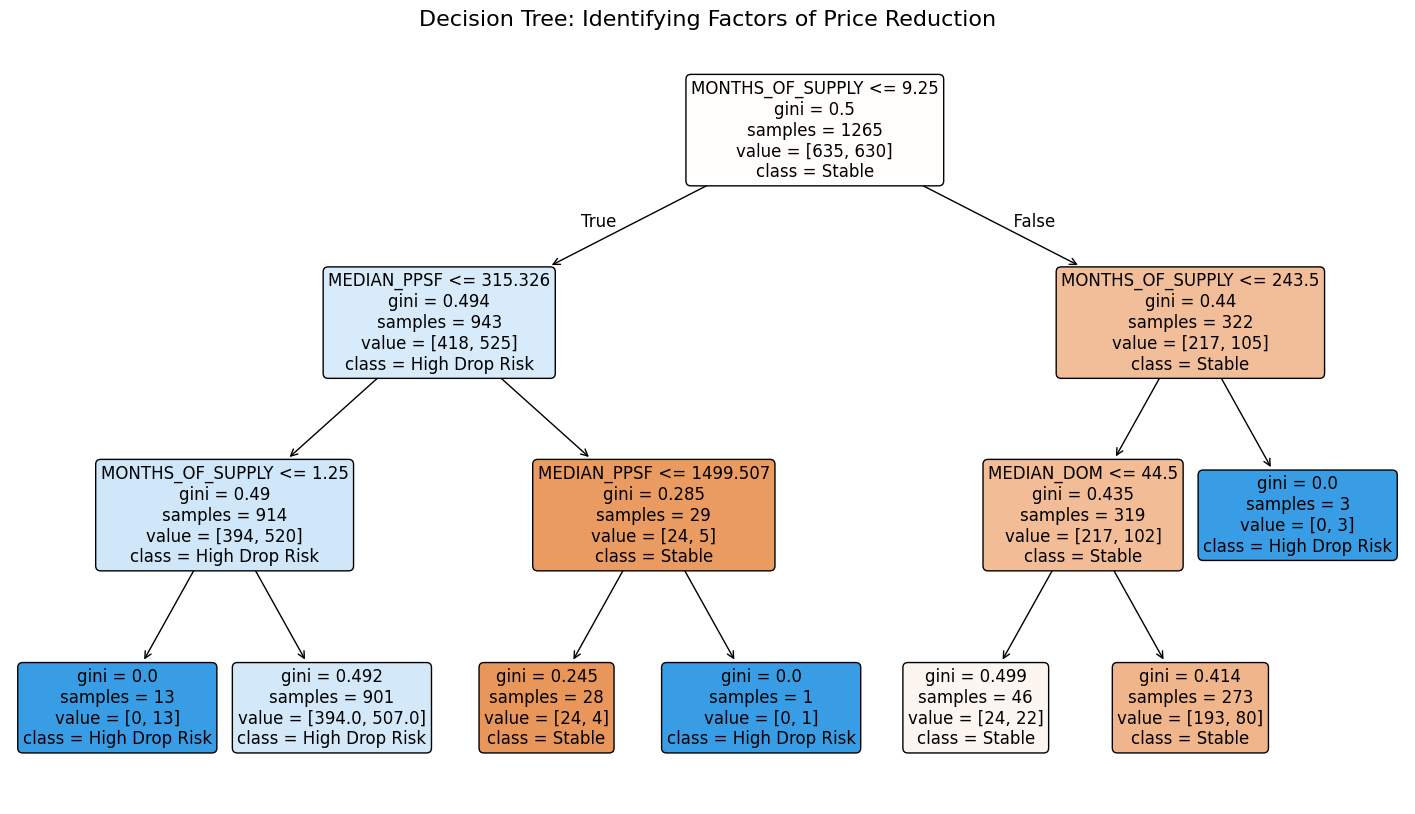

In [ ]:
# DECISION TREE 

threshold = clean_df['PRICE_DROPS'].median()
clean_df['High_Drop_Prob'] = (clean_df['PRICE_DROPS'] > threshold).astype(int)


X_tree = clean_df[['MEDIAN_DOM', 'MONTHS_OF_SUPPLY', 'MEDIAN_PPSF']]
y_tree = clean_df['High_Drop_Prob']


clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

# The Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(
    clf, 
    feature_names=X_tree.columns, 
    class_names=['Stable', 'High Drop Risk'], 
    filled=True, 
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree: Identifying Factors of Price Reduction', fontsize=16)
plt.show()

With this decision tree, we will see the entire Texas housing market including rural areas. The majority of normal Texas markets where supply is under 9 months, the tree shows that if a home have median price per square foot under $315, it classifying as a high drop risk. Therefor, the mainstream market is classified as a high drop risk. On the other hand, the luxury market which has the median price per square foot over $315 is classified stable. This comfirms the K-Means clustering: the luxury market are holding the values while sellers in mainstream market are being forced to slash prices to sell homes. 

### Conclusion & Business Recommendations
Based on data processing, visualization, and machine learning models applied to the early 2026 dataset, we can conclude:

- The 2026 market is fragmented: Texas is no longer a "hot" market across the board. Buyers need to consider local data rather than statewide trends.

- Time is leverage: Decision trees confirm that as the number of days on market (DOM) increases beyond the first split, the probability of price drops skyrockets. Buyers should target homes that have been on the market longer than the state average to maximize their negotiating power.

- Beware of "comb-shaped" data: Filtering by sales volume is crucial to this analysis, demonstrating that raw data needs to be considered in its specific context before relying on percentage-based growth indicators.